#### Replay State workflow (using checkpoint)

Boilerplate code

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
import warnings

warnings.filterwarnings("ignore")

load_dotenv() 

google_api_key = os.getenv("../.env/GOOGLE_API_KEY")

google_llm=ChatGoogleGenerativeAI(
    temperature=0,
    model="gemini-3.5-flash-lite",
    api_key=google_api_key,
    max_tokens=200
)
if google_llm:
    print("API loaded successfully")


API loaded successfully


Graph

In [3]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm_with_tools = google_llm.bind_tools(tools)

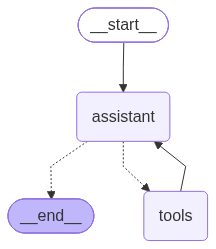

In [4]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(checkpointer=MemorySaver())

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

test

In [5]:
initial_input = {"messages":HumanMessage(content="Multiply 2 and 3")}

config = {"configurable":{"thread_id":1}}

for event in graph.stream(initial_input,config,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (TrBbhKE1)
 Call ID: TrBbhKE1
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The result of multiplying 2 and 3 is 6.', 'extras': {'signature': 'EjQKMgERTTIP9FL5iKf3xBuZXFI3IefzkzeawnNIl0YFt8wCMWlzcaEHtV/+OoxuJPFzSx6R'}}]


In [6]:
all_states =[s for s in graph.get_state_history(config)]

for msg in all_states[-5].values.get('messages'):
    msg.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (TrBbhKE1)
 Call ID: TrBbhKE1
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The result of multiplying 2 and 3 is 6.', 'extras': {'signature': 'EjQKMgERTTIP9FL5iKf3xBuZXFI3IefzkzeawnNIl0YFt8wCMWlzcaEHtV/+OoxuJPFzSx6R'}}]


##### States are updated in Newest to oldest sorting order
[-2] : first meaningful state. as [-1] is just Empty(initialization of the graph)

In [7]:
to_reply_state = all_states[-2]
to_reply_state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='baefe527-6dd4-42af-9f51-79ff12a4b457')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18d97b-fbd0-69db-8000-914a758f559b'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-01T10:57:12.161106+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18d97b-fbb0-6881-bfff-d134c1b4f3b0'}}, tasks=(PregelTask(id='ae55f970-794f-84a6-0770-5bf4b2a06217', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}, '__gemini_function_call_thought_signatures__': {'TrBbhKE1': 'EjQKMgERTTIPXIq0OO3IRo+U2G4OZ6tj1aYZH83tmctn0EMZ9aCPwu2rx4T4lUHuekRkAPBp'}}, response_metadata={'finish_reas

In [8]:
to_reply_state.values

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='baefe527-6dd4-42af-9f51-79ff12a4b457')]}

In [9]:
to_reply_state.next


('assistant',)

In [10]:
to_reply_state.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18d97b-fbd0-69db-8000-914a758f559b'}}

If we invoke again with the "config id", it just re runs from the checkpoint_id

In [11]:
for event in graph.stream(None, to_reply_state.config,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (j4S1tIj4)
 Call ID: j4S1tIj4
  Args:
    b: 3
    a: 2
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The result of multiplying 2 and 3 is 6.', 'extras': {'signature': 'EjQKMgERTTIPgWDhFUk7zGucWNCHRpB4RBFE0+CviMuJ5PV72kntC1HuumRMjXjT9dbOD9oA'}}]


Checking the history (the state will be displayed two times as we re run the states)

In [12]:
state_history = [s for s in graph.get_state_history(config)]

for state in state_history:
    for msg in state.values.get("messages"):
        msg.pretty_print()
    print("===== END =====")

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (j4S1tIj4)
 Call ID: j4S1tIj4
  Args:
    b: 3
    a: 2
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The result of multiplying 2 and 3 is 6.', 'extras': {'signature': 'EjQKMgERTTIPgWDhFUk7zGucWNCHRpB4RBFE0+CviMuJ5PV72kntC1HuumRMjXjT9dbOD9oA'}}]
===== END =====
================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (j4S1tIj4)
 Call ID: j4S1tIj4
  Args:
    b: 3
    a: 2
================================= Tool Message =================================
Name: multiply

6
===== E

Forking a state ( to replay with a different value. )

In [13]:
forked_state = all_states[-2]
forked_state.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18d97b-fbd0-69db-8000-914a758f559b'}}

In [14]:
forked_state_update_config = graph.update_state(
    forked_state.config,
    {"messages":[HumanMessage(
        content="Multiply 5 and 10",
        id = forked_state.values['messages'][0].id
    )]}
)
forked_state_update_config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18d9a7-aa28-6b47-8001-403ef0987f86'}}

In [15]:
all_states = [state for state in graph.get_state_history(config)]
all_states[0].values["messages"]

[HumanMessage(content='Multiply 5 and 10', additional_kwargs={}, response_metadata={}, id='baefe527-6dd4-42af-9f51-79ff12a4b457')]

Checking history

In [16]:
state_history = [s for s in graph.get_state_history(config)]

for state in state_history:
    for msg in state.values.get("messages"):
        msg.pretty_print()
    print("===== END =====")

================================ Human Message =================================

Multiply 5 and 10
===== END =====
================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (j4S1tIj4)
 Call ID: j4S1tIj4
  Args:
    b: 3
    a: 2
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The result of multiplying 2 and 3 is 6.', 'extras': {'signature': 'EjQKMgERTTIPgWDhFUk7zGucWNCHRpB4RBFE0+CviMuJ5PV72kntC1HuumRMjXjT9dbOD9oA'}}]
===== END =====
================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (j4S1tIj4)
 Call ID: j4S1tIj4
  Args:
    b: 3